✅ rim vents generated: n_vents=138 (spacing=50.0 m)
   lava threshold=0.5 m, simplify=5.0 m
✅ thickness stats [m]: 0.0 0.9149438142776489 6.499329566955566 10.509571075439453
✅ zoffset stats [m]: 0.0 0.9149438142776489 6.499329566955566 10.509571075439453
✅ mask quicklook → energy_cone_mu_0.30_rimvents_zoffset_from_thickness/lava_mask.png
✅ zoffset quicklook → energy_cone_mu_0.30_rimvents_zoffset_from_thickness/rim_vents_zoffset.png


/var/folders/xd/msh5srmj40702mpq6nhmmpjw0000gn/T/ipykernel_88392/3916050954.py:309: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_union.to_file(shp_union)
/Users/tomo/Documents/Numerical/EnergyCone/.venvec/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'rim_spacing_m' to 'rim_spacin'
  ogr_write(


✅ union Shapefile → energy_cone_mu_0.30_rimvents_zoffset_from_thickness/merged_mu_0.30_union_zoffset_from_thickness.shp


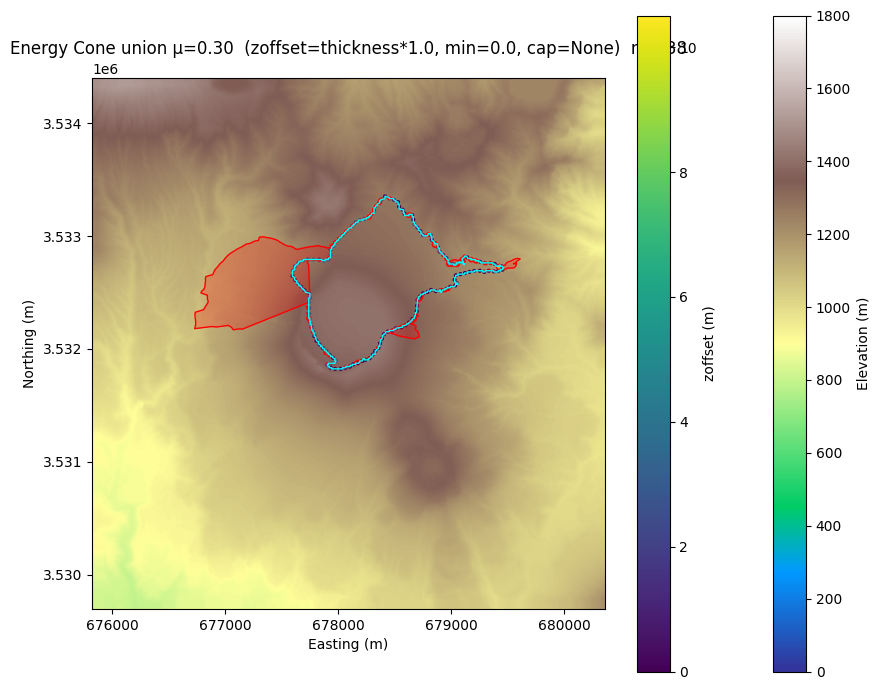

✅ union PNG → energy_cone_mu_0.30_rimvents_zoffset_from_thickness/merged_mu_0.30_union_zoffset_from_thickness.png


In [2]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, LineString
from shapely.ops import unary_union
from rasterio.warp import reproject, Resampling
from rasterio.features import shapes
from shapely.geometry import shape as shp_shape
import os

# =========================================================
# 入力
# =========================================================
dem_with_lava_tif = "../demShinmoeRL2025N.tif"          # 溶岩あり（現状のDEM）
dem_no_lava_tif   = "../demShinmoe2025_nolava.tif"      # 溶岩なし

mu = 0.30
crs_epsg = "EPSG:6689"
az_step_deg = 1.0

# vents生成パラメータ
rim_spacing_m = 50.0
thickness_threshold_m = 0.5
simplify_m = 5.0
min_area_m2 = 0.0

# ★ zoffset（厚さ→立上げ高度）設定
zoffset_min_m = 0.0          # 0にしたくなければ 1.0 など
zoffset_scale = 1.0          # 厚さをそのまま使うなら 1.0（例: 0.3 にすると弱める）
zoffset_cap_m = None         # 上限を付けたいなら 50.0 等（m）

# 出力
root_dir = f"energy_cone_mu_{mu:.2f}_rimvents_zoffset_from_thickness"
os.makedirs(root_dir, exist_ok=True)

# =========================================================
# 1) 参照格子に合わせて2枚のDEMを揃えて読む（必要ならリサンプル）
# =========================================================
def _read_as_ref_grid(src_path, ref_profile):
    with rasterio.open(src_path) as src:
        arr = src.read(1).astype(np.float32)
        sp = src.profile

        same_grid = (
            sp["crs"] == ref_profile["crs"] and
            sp["transform"] == ref_profile["transform"] and
            sp["width"] == ref_profile["width"] and
            sp["height"] == ref_profile["height"]
        )
        if same_grid:
            return arr, sp

        out = np.full((ref_profile["height"], ref_profile["width"]), np.nan, dtype=np.float32)
        reproject(
            source=arr,
            destination=out,
            src_transform=sp["transform"],
            src_crs=sp["crs"],
            dst_transform=ref_profile["transform"],
            dst_crs=ref_profile["crs"],
            resampling=Resampling.bilinear,
            src_nodata=sp.get("nodata", None),
            dst_nodata=np.nan
        )
        sp2 = ref_profile.copy()
        sp2["dtype"] = "float32"
        sp2["nodata"] = np.nan
        return out, sp2

with rasterio.open(dem_with_lava_tif) as srcL:
    dem = srcL.read(1).astype(np.float32)
    transform = srcL.transform
    bounds = srcL.bounds
    dem_crs = srcL.crs
    dem_profile = srcL.profile
    invA = ~transform

extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
rows, cols = dem.shape
px = (abs(transform.a) + abs(transform.e)) * 0.5
dr = px

# 溶岩なしを溶岩あり格子へ合わせて読む
dem_nolava, _ = _read_as_ref_grid(dem_no_lava_tif, dem_profile)

# =========================================================
# 2) 差分で溶岩域マスク → ポリゴン → 外周リム → vents
# =========================================================
diff = dem - dem_nolava
mask = np.isfinite(diff) & (diff >= thickness_threshold_m)

geoms = []
for geom, val in shapes(mask.astype(np.uint8), mask=mask, transform=transform):
    if val != 1:
        continue
    poly = shp_shape(geom)
    if (min_area_m2 > 0) and (poly.area < min_area_m2):
        continue
    geoms.append(poly)

if not geoms:
    raise RuntimeError("溶岩域が抽出できませんでした。thickness_threshold_m を下げる等で調整してください。")

lava_poly = unary_union(geoms)
if lava_poly.geom_type == "MultiPolygon":
    lava_poly = max(list(lava_poly.geoms), key=lambda p: p.area)

if simplify_m and simplify_m > 0:
    lava_poly = lava_poly.simplify(simplify_m, preserve_topology=True)

# CRSを指定（DEMと同じ）→EPSG:6689へ
gdf_lava = gpd.GeoDataFrame(geometry=[lava_poly], crs=dem_crs).to_crs(crs_epsg)
lava_poly = gdf_lava.geometry.iloc[0]

rim = LineString(lava_poly.exterior.coords)
L = rim.length
n = max(3, int(np.floor(L / rim_spacing_m)))
dists = np.linspace(0, L, n, endpoint=False)

# =========================================================
# ★ 2.5) vents + ventごとの zoffset（厚さ）を作る
# =========================================================
def sample_grid_bilinear(arr, x, y):
    col_f, row_f = invA * (x, y)
    if (col_f < 0) or (row_f < 0) or (col_f > cols - 1) or (row_f > rows - 1):
        return np.nan
    c0 = int(np.floor(col_f)); r0 = int(np.floor(row_f))
    c1 = min(c0 + 1, cols - 1); r1 = min(r0 + 1, rows - 1)
    dc = col_f - c0; drf = row_f - r0
    z00 = arr[r0, c0]; z10 = arr[r0, c1]
    z01 = arr[r1, c0]; z11 = arr[r1, c1]
    z0_ = z00 * (1 - dc) + z10 * dc
    z1_ = z01 * (1 - dc) + z11 * dc
    return float(z0_ * (1 - drf) + z1_ * drf)

vents = []
zoffsets = []
thicknesses = []

for d in dists:
    p = rim.interpolate(d)
    x, y = float(p.x), float(p.y)

    th = sample_grid_bilinear(diff, x, y)
    if not np.isfinite(th):
        th = 0.0
    th = max(0.0, th)  # 念のため（負厚さを潰す）

    zo = zoffset_scale * th
    zo = max(zoffset_min_m, zo)
    if zoffset_cap_m is not None:
        zo = min(zoffset_cap_m, zo)

    vents.append((x, y))
    thicknesses.append(th)
    zoffsets.append(zo)

thicknesses = np.asarray(thicknesses, dtype=np.float32)
zoffsets = np.asarray(zoffsets, dtype=np.float32)

print(f"✅ rim vents generated: n_vents={len(vents)} (spacing={rim_spacing_m} m)")
print(f"   lava threshold={thickness_threshold_m} m, simplify={simplify_m} m")
print("✅ thickness stats [m]:",
      float(np.nanmin(thicknesses)),
      float(np.nanpercentile(thicknesses, 50)),
      float(np.nanpercentile(thicknesses, 95)),
      float(np.nanmax(thicknesses)))
print("✅ zoffset stats [m]:",
      float(np.nanmin(zoffsets)),
      float(np.nanpercentile(zoffsets, 50)),
      float(np.nanpercentile(zoffsets, 95)),
      float(np.nanmax(zoffsets)))

# （任意）確認用：マスクとリムventsのチェック図を保存
fig, ax = plt.subplots(figsize=(7,7))
ax.imshow(mask, origin="upper")
ax.set_title("Lava mask (diff >= threshold)")
plt.tight_layout()
mask_png = os.path.join(root_dir, "lava_mask.png")
plt.savefig(mask_png, dpi=200)
plt.close(fig)
print("✅ mask quicklook →", mask_png)

# ★（任意）zoffsetの空間分布をチェック（保存）
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(dem, cmap="terrain", extent=extent, origin="upper", vmin=0, vmax=1800)
sc = ax.scatter([x for x,y in vents], [y for x,y in vents], c=zoffsets, s=6)
plt.colorbar(sc, ax=ax, label="zoffset from lava thickness (m)")
gdf_lava.boundary.plot(ax=ax, color="cyan", linewidth=1.0)
ax.set_title("Rim vents colored by zoffset (thickness)")
plt.tight_layout()
zoff_png = os.path.join(root_dir, "rim_vents_zoffset.png")
plt.savefig(zoff_png, dpi=200)
plt.close(fig)
print("✅ zoffset quicklook →", zoff_png)

# =========================================================
# 3) エナジーコーン（merge-only）— ventごと zoffset を使用
# =========================================================
def sample_dem_bilinear(x, y):
    col_f, row_f = invA * (x, y)
    if (col_f < 0) or (row_f < 0) or (col_f > cols - 1) or (row_f > rows - 1):
        return np.nan
    c0 = int(np.floor(col_f)); r0 = int(np.floor(row_f))
    c1 = min(c0 + 1, cols - 1); r1 = min(r0 + 1, rows - 1)
    dc = col_f - c0; drf = row_f - r0
    z00 = dem[r0, c0]; z10 = dem[r0, c1]
    z01 = dem[r1, c0]; z11 = dem[r1, c1]
    z0_ = z00 * (1 - dc) + z10 * dc
    z1_ = z01 * (1 - dc) + z11 * dc
    return float(z0_ * (1 - drf) + z1_ * drf)

def raycast_boundary_for_vent(x0, y0, mu, zoffset_i, az_step_deg=1.0, dr=10.0):
    col0, row0 = invA * (x0, y0)
    col0 = int(np.clip(np.floor(col0), 0, cols-1))
    row0 = int(np.clip(np.floor(row0), 0, rows-1))
    z0 = float(dem[row0, col0])

    corners = [(extent[0], extent[2]), (extent[0], extent[3]),
               (extent[1], extent[2]), (extent[1], extent[3])]
    r_max_bound = max(np.hypot(x0 - cx, y0 - cy) for (cx, cy) in corners) + 2 * dr

    az_list = np.arange(0.0, 360.0, az_step_deg)
    stop_xy = []

    for az in az_list:
        rad = np.deg2rad(az); dx = np.cos(rad); dy = np.sin(rad)
        r = 0.0
        zt_prev = sample_dem_bilinear(x0, y0)
        zc_prev = z0 + zoffset_i
        hit = None

        while r <= r_max_bound:
            r += dr
            x = x0 + r * dx
            y = y0 + r * dy

            zt = sample_dem_bilinear(x, y)
            if np.isnan(zt):
                break

            zc = z0 + zoffset_i - mu * r

            if zt >= zc:
                r1 = r - dr
                f0 = zc_prev - zt_prev
                f1 = zc - zt
                alpha = 0.0
                if (f0 - f1) != 0:
                    alpha = np.clip(f0 / (f0 - f1), 0.0, 1.0)
                r_star = r1 + alpha * dr
                x_star = x0 + r_star * dx
                y_star = y0 + r_star * dy
                hit = (x_star, y_star)
                break

            zc_prev, zt_prev = zc, zt

        if hit is None:
            hit = (x, y)

        stop_xy.append(hit)

    poly = None
    pts = np.asarray(stop_xy)
    if len(pts) >= 3:
        poly = Polygon(pts)
        if not poly.is_valid:
            poly = poly.buffer(0)

    return poly

# ventsが多いと激重なので、まず間引き（必要なら有効化）
# vents = vents[::2]; zoffsets = zoffsets[::2]

polys = []
for (x0, y0), zo in zip(vents, zoffsets):
    poly = raycast_boundary_for_vent(x0, y0, mu, float(zo), az_step_deg=az_step_deg, dr=dr)
    if (poly is not None) and (not poly.is_empty):
        polys.append(poly)

if not polys:
    raise RuntimeError("有効ポリゴンが作れませんでした（μ/az_step_deg/dr/zoffset設定を確認）")

union_geom = unary_union(polys)
gdf_union = gpd.GeoDataFrame(
    {
        "mu":[mu],
        "n_vents":[len(vents)],
        "az_step":[az_step_deg],
        "dr_m":[dr],
        "rim_spacing_m":[rim_spacing_m],
        "thresh_m":[thickness_threshold_m],
        "simplify_m":[simplify_m],
        "zmin_m":[float(np.min(zoffsets))],
        "zmed_m":[float(np.percentile(zoffsets, 50))],
        "z95_m":[float(np.percentile(zoffsets, 95))],
        "zmax_m":[float(np.max(zoffsets))],
        "zscale":[zoffset_scale],
        "zcap_m":[-1.0 if zoffset_cap_m is None else float(zoffset_cap_m)],
        "zminfloor":[float(zoffset_min_m)],
    },
    geometry=[union_geom],
    crs=crs_epsg
)

shp_union = os.path.join(root_dir, f"merged_mu_{mu:.2f}_union_zoffset_from_thickness.shp")
gdf_union.to_file(shp_union)
print("✅ union Shapefile →", shp_union)

# union PNG
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(dem, cmap="terrain", extent=extent, origin="upper", vmin=0, vmax=1800)
plt.colorbar(im, ax=ax, label="Elevation (m)")
ax.set_title(
    f"Energy Cone union μ={mu:.2f}  (zoffset=thickness*{zoffset_scale}, "
    f"min={zoffset_min_m}, cap={zoffset_cap_m})  n={len(vents)}"
)

# 溶岩外周（確認用）
gdf_lava.boundary.plot(ax=ax, color="cyan", linewidth=1.0, zorder=6)

# union
gdf_union.plot(ax=ax, facecolor=(1,0,0,0.25), edgecolor="red", linewidth=1.0, zorder=5)

# vents点（色でzoffset）
sc = ax.scatter([x for x,y in vents], [y for x,y in vents], c=zoffsets, s=4)
plt.colorbar(sc, ax=ax, label="zoffset (m)")

ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout()

out_png = os.path.join(root_dir, f"merged_mu_{mu:.2f}_union_zoffset_from_thickness.png")
plt.savefig(out_png, dpi=300)
plt.show()
print("✅ union PNG →", out_png)


✅ rim vents generated: n_vents=138 (spacing=50.0 m)
   lava threshold=0.5 m, simplify=5.0 m
✅ thickness stats [m]: 0.0 0.9149438142776489 6.499329566955566 10.509571075439453
✅ mask quicklook → energy_cone_mu_0.25_rimvents_zoffset_from_thickness/lava_mask.png
✅ zoffset quicklook → energy_cone_mu_0.25_rimvents_zoffset_from_thickness/rim_vents_zoffset.png
✅ scale-law check samples: n=97
✅ H_obs/H_s ratio: median= 1.1506306431338866  p16–p84= 0.2287484831761499 – 3.346180741810305


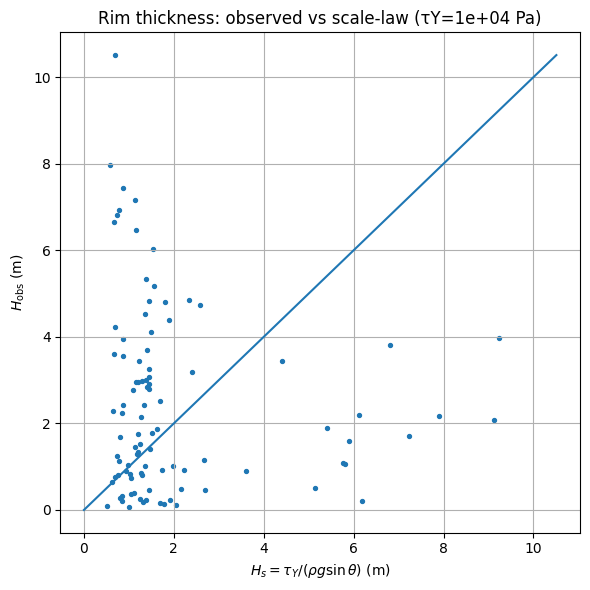

✅ plot → energy_cone_mu_0.25_rimvents_zoffset_from_thickness/rim_Hobs_vs_Hs_scalelaw.png


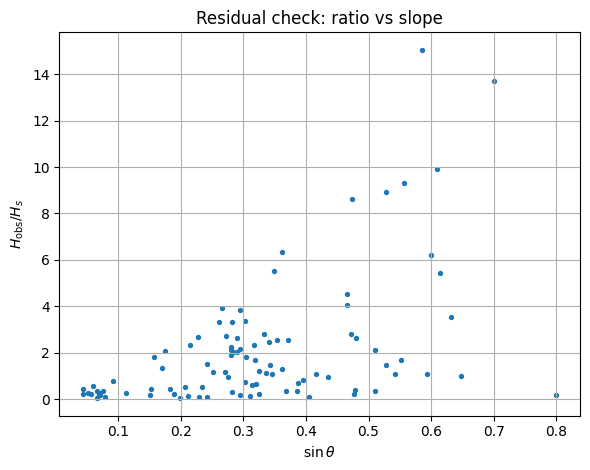

✅ plot → energy_cone_mu_0.25_rimvents_zoffset_from_thickness/rim_ratio_vs_sinTheta.png


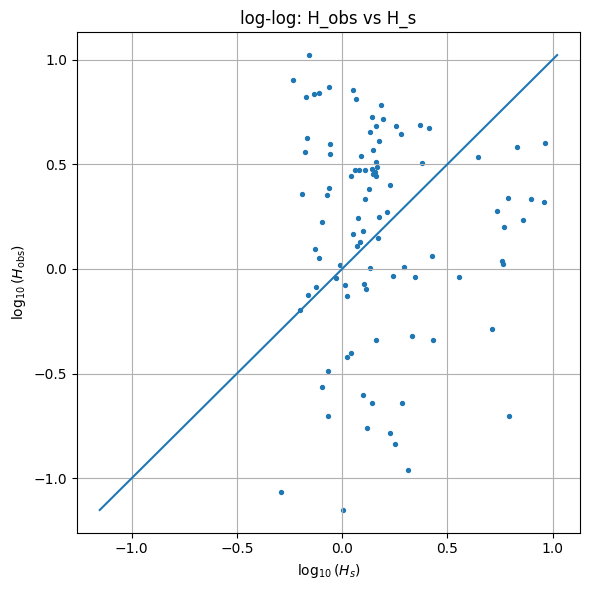

✅ plot → energy_cone_mu_0.25_rimvents_zoffset_from_thickness/rim_Hobs_vs_Hs_scalelaw_loglog.png


/var/folders/xd/msh5srmj40702mpq6nhmmpjw0000gn/T/ipykernel_72006/828838932.py:412: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_union.to_file(shp_union)
/Users/tomo/Documents/Numerical/EnergyCone/.venvec/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'rim_spacing_m' to 'rim_spacin'
  ogr_write(


✅ union Shapefile → energy_cone_mu_0.25_rimvents_zoffset_from_thickness/merged_mu_0.25_union_zoffset_from_thickness.shp


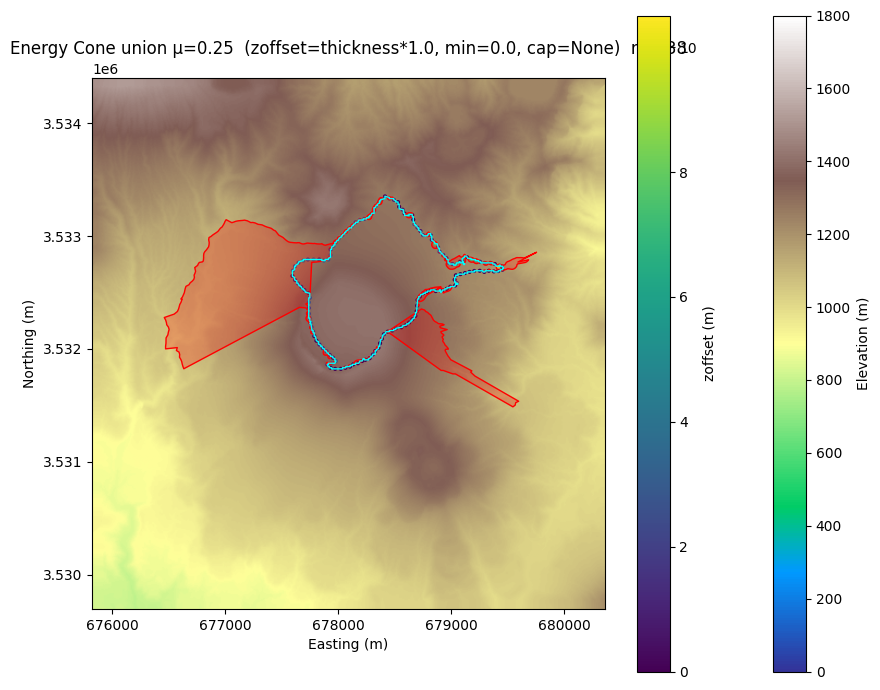

✅ union PNG → energy_cone_mu_0.25_rimvents_zoffset_from_thickness/merged_mu_0.25_union_zoffset_from_thickness.png


In [1]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, LineString
from shapely.ops import unary_union
from rasterio.warp import reproject, Resampling
from rasterio.features import shapes
from shapely.geometry import shape as shp_shape
import os

# =========================================================
# 入力
# =========================================================
dem_with_lava_tif = "../demShinmoeRL2025N.tif"          # 溶岩あり（現状のDEM）
dem_no_lava_tif   = "../demShinmoe2025_nolava.tif"      # 溶岩なし

mu = 0.25
crs_epsg = "EPSG:6689"
az_step_deg = 1.0

# vents生成パラメータ
rim_spacing_m = 50.0
thickness_threshold_m = 0.5
simplify_m = 5.0
min_area_m2 = 0.0

# ★ zoffset（厚さ→立上げ高度）設定（エナジーコーン用）
zoffset_min_m = 0.0
zoffset_scale = 1.0
zoffset_cap_m = None

# ★ 厚みスケール則（検証したい式）
#   H_s = tauY / (rho g sinθ)
tauY = 1.0e4      # Pa
rho  = 2500.0     # kg/m3
g    = 9.8        # m/s2
min_sin_theta = 1e-3        # sinθが小さすぎる点は除外（発散防止）
min_thickness_plot = 0.05   # 実測厚さが薄すぎる点は除外（ノイズ対策）

# 出力
root_dir = f"energy_cone_mu_{mu:.2f}_rimvents_zoffset_from_thickness"
os.makedirs(root_dir, exist_ok=True)

# =========================================================
# 1) 参照格子に合わせて2枚のDEMを揃えて読む（必要ならリサンプル）
# =========================================================
def _read_as_ref_grid(src_path, ref_profile):
    with rasterio.open(src_path) as src:
        arr = src.read(1).astype(np.float32)
        sp = src.profile

        same_grid = (
            sp["crs"] == ref_profile["crs"] and
            sp["transform"] == ref_profile["transform"] and
            sp["width"] == ref_profile["width"] and
            sp["height"] == ref_profile["height"]
        )
        if same_grid:
            return arr, sp

        out = np.full((ref_profile["height"], ref_profile["width"]), np.nan, dtype=np.float32)
        reproject(
            source=arr,
            destination=out,
            src_transform=sp["transform"],
            src_crs=sp["crs"],
            dst_transform=ref_profile["transform"],
            dst_crs=ref_profile["crs"],
            resampling=Resampling.bilinear,
            src_nodata=sp.get("nodata", None),
            dst_nodata=np.nan
        )
        sp2 = ref_profile.copy()
        sp2["dtype"] = "float32"
        sp2["nodata"] = np.nan
        return out, sp2

with rasterio.open(dem_with_lava_tif) as srcL:
    dem = srcL.read(1).astype(np.float32)
    transform = srcL.transform
    bounds = srcL.bounds
    dem_crs = srcL.crs
    dem_profile = srcL.profile
    invA = ~transform

extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
rows, cols = dem.shape
px = (abs(transform.a) + abs(transform.e)) * 0.5
dr = px

# 溶岩なしを溶岩あり格子へ合わせて読む
dem_nolava, _ = _read_as_ref_grid(dem_no_lava_tif, dem_profile)

# =========================================================
# 2) 差分で溶岩域マスク → ポリゴン → 外周リム → vents
# =========================================================
diff = dem - dem_nolava
mask = np.isfinite(diff) & (diff >= thickness_threshold_m)

geoms = []
for geom, val in shapes(mask.astype(np.uint8), mask=mask, transform=transform):
    if val != 1:
        continue
    poly = shp_shape(geom)
    if (min_area_m2 > 0) and (poly.area < min_area_m2):
        continue
    geoms.append(poly)

if not geoms:
    raise RuntimeError("溶岩域が抽出できませんでした。thickness_threshold_m を下げる等で調整してください。")

lava_poly = unary_union(geoms)
if lava_poly.geom_type == "MultiPolygon":
    lava_poly = max(list(lava_poly.geoms), key=lambda p: p.area)

if simplify_m and simplify_m > 0:
    lava_poly = lava_poly.simplify(simplify_m, preserve_topology=True)

# CRSを指定（DEMと同じ）→EPSG:6689へ
gdf_lava = gpd.GeoDataFrame(geometry=[lava_poly], crs=dem_crs).to_crs(crs_epsg)
lava_poly = gdf_lava.geometry.iloc[0]

rim = LineString(lava_poly.exterior.coords)
L = rim.length
n = max(3, int(np.floor(L / rim_spacing_m)))
dists = np.linspace(0, L, n, endpoint=False)

# =========================================================
# ★ 共通：バイリニアサンプル（任意グリッド）
# =========================================================
def sample_grid_bilinear(arr, x, y):
    col_f, row_f = invA * (x, y)
    if (col_f < 0) or (row_f < 0) or (col_f > cols - 1) or (row_f > rows - 1):
        return np.nan
    c0 = int(np.floor(col_f)); r0 = int(np.floor(row_f))
    c1 = min(c0 + 1, cols - 1); r1 = min(r0 + 1, rows - 1)
    dc = col_f - c0; drf = row_f - r0
    z00 = arr[r0, c0]; z10 = arr[r0, c1]
    z01 = arr[r1, c0]; z11 = arr[r1, c1]
    z0_ = z00 * (1 - dc) + z10 * dc
    z1_ = z01 * (1 - dc) + z11 * dc
    return float(z0_ * (1 - drf) + z1_ * drf)

# =========================================================
# ★ 2.5) vents + ventごとの zoffset（厚さ）を作る
# =========================================================
vents = []
zoffsets = []
thicknesses = []

for d in dists:
    p = rim.interpolate(d)
    x, y = float(p.x), float(p.y)

    th = sample_grid_bilinear(diff, x, y)
    if not np.isfinite(th):
        th = 0.0
    th = max(0.0, th)

    zo = zoffset_scale * th
    zo = max(zoffset_min_m, zo)
    if zoffset_cap_m is not None:
        zo = min(zoffset_cap_m, zo)

    vents.append((x, y))
    thicknesses.append(th)
    zoffsets.append(zo)

thicknesses = np.asarray(thicknesses, dtype=np.float32)
zoffsets = np.asarray(zoffsets, dtype=np.float32)

print(f"✅ rim vents generated: n_vents={len(vents)} (spacing={rim_spacing_m} m)")
print(f"   lava threshold={thickness_threshold_m} m, simplify={simplify_m} m")
print("✅ thickness stats [m]:",
      float(np.nanmin(thicknesses)),
      float(np.nanpercentile(thicknesses, 50)),
      float(np.nanpercentile(thicknesses, 95)),
      float(np.nanmax(thicknesses)))

# （任意）確認用：マスク quicklook
fig, ax = plt.subplots(figsize=(7,7))
ax.imshow(mask, origin="upper")
ax.set_title("Lava mask (diff >= threshold)")
plt.tight_layout()
mask_png = os.path.join(root_dir, "lava_mask.png")
plt.savefig(mask_png, dpi=200)
plt.close(fig)
print("✅ mask quicklook →", mask_png)

# （任意）zoffsetの空間分布 quicklook
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(dem, cmap="terrain", extent=extent, origin="upper", vmin=0, vmax=1800)
sc = ax.scatter([x for x,y in vents], [y for x,y in vents], c=zoffsets, s=6)
plt.colorbar(sc, ax=ax, label="zoffset from lava thickness (m)")
gdf_lava.boundary.plot(ax=ax, color="cyan", linewidth=1.0)
ax.set_title("Rim vents colored by zoffset (thickness)")
plt.tight_layout()
zoff_png = os.path.join(root_dir, "rim_vents_zoffset.png")
plt.savefig(zoff_png, dpi=200)
plt.close(fig)
print("✅ zoffset quicklook →", zoff_png)

# =========================================================
# ★ 2.6) スケール則検証：H_obs vs H_s = tauY/(rho g sinθ)
#     θは「溶岩なしDEM」の局所傾斜角
# =========================================================
# slope (no-lava) -> theta -> sin(theta)
dzdx, dzdy = np.gradient(dem_nolava, px, px)
theta_rad = np.arctan(np.sqrt(dzdx**2 + dzdy**2))
sin_theta_grid = np.sin(theta_rad)

H_obs_list = []
H_s_list = []
sin_list = []

# vents（rim点）で比較：実測厚さは diff、モデルは sinθ から計算
for (x, y) in vents:
    H_obs = sample_grid_bilinear(diff, x, y)            # m
    s = sample_grid_bilinear(sin_theta_grid, x, y)      # dimensionless

    if not (np.isfinite(H_obs) and np.isfinite(s)):
        continue

    H_obs = max(0.0, float(H_obs))
    s = float(s)

    if H_obs < min_thickness_plot:
        continue
    if s < min_sin_theta:
        continue

    H_s = tauY / (rho * g * s)  # m

    H_obs_list.append(H_obs)
    H_s_list.append(H_s)
    sin_list.append(s)

H_obs_arr = np.asarray(H_obs_list, dtype=np.float64)
H_s_arr = np.asarray(H_s_list, dtype=np.float64)
sin_arr = np.asarray(sin_list, dtype=np.float64)

print(f"✅ scale-law check samples: n={len(H_obs_arr)}")
if len(H_obs_arr) < 3:
    print("⚠ サンプルが少なすぎて比較プロットが不安定かもしれません。threshold等を調整してください。")
else:
    ratio = H_obs_arr / H_s_arr
    print("✅ H_obs/H_s ratio: median=",
          float(np.median(ratio)),
          " p16–p84=",
          float(np.percentile(ratio, 16)), "–", float(np.percentile(ratio, 84)))

# (A) H_obs vs H_s scatter (1:1 line)
if len(H_obs_arr) > 0:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(H_s_arr, H_obs_arr, s=8)
    mmax = float(max(np.max(H_s_arr), np.max(H_obs_arr)))
    ax.plot([0, mmax], [0, mmax], lw=1.5)  # 1:1
    ax.set_xlabel(r"$H_s=\tau_Y/(\rho g \sin\theta)$ (m)")
    ax.set_ylabel(r"$H_{\mathrm{obs}}$ (m)")
    ax.set_title(rf"Rim thickness: observed vs scale-law (τY={tauY:.0e} Pa)")
    ax.grid(True)
    plt.tight_layout()
    out_scatter = os.path.join(root_dir, "rim_Hobs_vs_Hs_scalelaw.png")
    plt.savefig(out_scatter, dpi=300)
    plt.show()
    print("✅ plot →", out_scatter)

# (B) residual view: ratio vs sinθ
if len(H_obs_arr) > 0:
    fig, ax = plt.subplots(figsize=(6, 4.8))
    ax.scatter(sin_arr, H_obs_arr / H_s_arr, s=8)
    ax.set_xlabel(r"$\sin\theta$")
    ax.set_ylabel(r"$H_{\mathrm{obs}}/H_s$")
    ax.set_title("Residual check: ratio vs slope")
    ax.grid(True)
    plt.tight_layout()
    out_ratio = os.path.join(root_dir, "rim_ratio_vs_sinTheta.png")
    plt.savefig(out_ratio, dpi=300)
    plt.show()
    print("✅ plot →", out_ratio)

# (C) log-log plot (optional)
good = (H_obs_arr > 0) & (H_s_arr > 0)
if np.any(good):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(np.log10(H_s_arr[good]), np.log10(H_obs_arr[good]), s=8)
    lo = float(min(np.min(np.log10(H_s_arr[good])), np.min(np.log10(H_obs_arr[good]))))
    hi = float(max(np.max(np.log10(H_s_arr[good])), np.max(np.log10(H_obs_arr[good]))))
    ax.plot([lo, hi], [lo, hi], lw=1.5)  # 1:1 in log space
    ax.set_xlabel(r"$\log_{10}(H_s)$")
    ax.set_ylabel(r"$\log_{10}(H_{\mathrm{obs}})$")
    ax.set_title("log-log: H_obs vs H_s")
    ax.grid(True)
    plt.tight_layout()
    out_log = os.path.join(root_dir, "rim_Hobs_vs_Hs_scalelaw_loglog.png")
    plt.savefig(out_log, dpi=300)
    plt.show()
    print("✅ plot →", out_log)

# =========================================================
# 3) エナジーコーン（merge-only）— ventごと zoffset を使用
# =========================================================
def sample_dem_bilinear(x, y):
    col_f, row_f = invA * (x, y)
    if (col_f < 0) or (row_f < 0) or (col_f > cols - 1) or (row_f > rows - 1):
        return np.nan
    c0 = int(np.floor(col_f)); r0 = int(np.floor(row_f))
    c1 = min(c0 + 1, cols - 1); r1 = min(r0 + 1, rows - 1)
    dc = col_f - c0; drf = row_f - r0
    z00 = dem[r0, c0]; z10 = dem[r0, c1]
    z01 = dem[r1, c0]; z11 = dem[r1, c1]
    z0_ = z00 * (1 - dc) + z10 * dc
    z1_ = z01 * (1 - dc) + z11 * dc
    return float(z0_ * (1 - drf) + z1_ * drf)

def raycast_boundary_for_vent(x0, y0, mu, zoffset_i, az_step_deg=1.0, dr=10.0):
    col0, row0 = invA * (x0, y0)
    col0 = int(np.clip(np.floor(col0), 0, cols-1))
    row0 = int(np.clip(np.floor(row0), 0, rows-1))
    z0 = float(dem[row0, col0])

    corners = [(extent[0], extent[2]), (extent[0], extent[3]),
               (extent[1], extent[2]), (extent[1], extent[3])]
    r_max_bound = max(np.hypot(x0 - cx, y0 - cy) for (cx, cy) in corners) + 2 * dr

    az_list = np.arange(0.0, 360.0, az_step_deg)
    stop_xy = []

    for az in az_list:
        rad = np.deg2rad(az); dx = np.cos(rad); dy = np.sin(rad)
        r = 0.0
        zt_prev = sample_dem_bilinear(x0, y0)
        zc_prev = z0 + zoffset_i
        hit = None

        while r <= r_max_bound:
            r += dr
            x = x0 + r * dx
            y = y0 + r * dy

            zt = sample_dem_bilinear(x, y)
            if np.isnan(zt):
                break

            zc = z0 + zoffset_i - mu * r

            if zt >= zc:
                r1 = r - dr
                f0 = zc_prev - zt_prev
                f1 = zc - zt
                alpha = 0.0
                if (f0 - f1) != 0:
                    alpha = np.clip(f0 / (f0 - f1), 0.0, 1.0)
                r_star = r1 + alpha * dr
                x_star = x0 + r_star * dx
                y_star = y0 + r_star * dy
                hit = (x_star, y_star)
                break

            zc_prev, zt_prev = zc, zt

        if hit is None:
            hit = (x, y)

        stop_xy.append(hit)

    poly = None
    pts = np.asarray(stop_xy)
    if len(pts) >= 3:
        poly = Polygon(pts)
        if not poly.is_valid:
            poly = poly.buffer(0)

    return poly

# ventsが多いと激重なので、まず間引き（必要なら有効化）
# vents = vents[::2]; zoffsets = zoffsets[::2]

polys = []
for (x0, y0), zo in zip(vents, zoffsets):
    poly = raycast_boundary_for_vent(x0, y0, mu, float(zo), az_step_deg=az_step_deg, dr=dr)
    if (poly is not None) and (not poly.is_empty):
        polys.append(poly)

if not polys:
    raise RuntimeError("有効ポリゴンが作れませんでした（μ/az_step_deg/dr/zoffset設定を確認）")

union_geom = unary_union(polys)
gdf_union = gpd.GeoDataFrame(
    {
        "mu":[mu],
        "n_vents":[len(vents)],
        "az_step":[az_step_deg],
        "dr_m":[dr],
        "rim_spacing_m":[rim_spacing_m],
        "thresh_m":[thickness_threshold_m],
        "simplify_m":[simplify_m],
        "zmin_m":[float(np.min(zoffsets))],
        "zmed_m":[float(np.percentile(zoffsets, 50))],
        "z95_m":[float(np.percentile(zoffsets, 95))],
        "zmax_m":[float(np.max(zoffsets))],
        "zscale":[zoffset_scale],
        "zcap_m":[-1.0 if zoffset_cap_m is None else float(zoffset_cap_m)],
        "zminfloor":[float(zoffset_min_m)],
    },
    geometry=[union_geom],
    crs=crs_epsg
)

shp_union = os.path.join(root_dir, f"merged_mu_{mu:.2f}_union_zoffset_from_thickness.shp")
gdf_union.to_file(shp_union)
print("✅ union Shapefile →", shp_union)

# union PNG
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(dem, cmap="terrain", extent=extent, origin="upper", vmin=0, vmax=1800)
plt.colorbar(im, ax=ax, label="Elevation (m)")
ax.set_title(
    f"Energy Cone union μ={mu:.2f}  (zoffset=thickness*{zoffset_scale}, "
    f"min={zoffset_min_m}, cap={zoffset_cap_m})  n={len(vents)}"
)

gdf_lava.boundary.plot(ax=ax, color="cyan", linewidth=1.0, zorder=6)
gdf_union.plot(ax=ax, facecolor=(1,0,0,0.25), edgecolor="red", linewidth=1.0, zorder=5)

sc = ax.scatter([x for x,y in vents], [y for x,y in vents], c=zoffsets, s=4)
plt.colorbar(sc, ax=ax, label="zoffset (m)")

ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout()

out_png = os.path.join(root_dir, f"merged_mu_{mu:.2f}_union_zoffset_from_thickness.png")
plt.savefig(out_png, dpi=300)
plt.show()
print("✅ union PNG →", out_png)